# Eksperimen Sistem Machine Learning - Heart Failure Detection

Notebook ini digunakan untuk melakukan eksperimen awal terhadap dataset Heart Failure Detection. Tahapan yang dilakukan meliputi data loading, exploratory data analysis (EDA), data preprocessing, dan penyimpanan dataset hasil preprocessing agar siap digunakan pada tahap pemodelan machine learning.

## 1. Perkenalan Dataset

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset yang digunakan adalah `heart_failure_detection.csv` (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction). Dataset ini berisi data tabular pasien dengan beberapa fitur klinis dan gaya hidup yang berkaitan dengan risiko penyakit jantung.

Target yang digunakan adalah kolom `HeartDisease`, sehingga masalah machine learning yang dikerjakan adalah supervised learning dengan task binary classification.

- `0`: tidak ada penyakit jantung
- `1`: ada penyakit jantung

## 2. Import Library

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

Library berikut digunakan untuk membaca data, melakukan eksplorasi, visualisasi, preprocessing, split data, dan menyimpan objek preprocessing.

In [10]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 3. Memuat Dataset

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

Dataset mentah dimuat dari folder `heart_failure_detection_raw`. Setelah data dimuat, dilakukan pengecekan awal terhadap bentuk data, beberapa baris pertama, tipe data, dan ringkasan statistik.

In [11]:
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "preprocessing" else Path.cwd()
DATA_PATH = ROOT_DIR / "heart_failure_detection_raw" / "heart_failure_detection.csv"
TARGET_COLUMN = "HeartDisease"
RANDOM_STATE = 42

raw_df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape dataset: {raw_df.shape}")
display(raw_df.head())

Dataset path: d:\.Projek\Dicoding\MSML_Muhammad-Fauzan-Ashshidiq\Eksperimen_SML_Muhammad-Fauzan-Ashshidiq\heart_failure_detection_raw\heart_failure_detection.csv
Shape dataset: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [12]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [13]:
display(raw_df.describe(include="all"))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


## 4. Exploratory Data Analysis (EDA)

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

EDA dilakukan untuk memahami struktur data, distribusi target, missing value, duplikasi, distribusi fitur numerik, dan relasi fitur kategorikal dengan target.

In [14]:
missing_values = raw_df.isna().sum().sort_values(ascending=False)
duplicate_count = raw_df.duplicated().sum()
target_distribution = raw_df[TARGET_COLUMN].value_counts().sort_index()

print("Missing values per column:")
display(missing_values)

print(f"Jumlah data duplikat: {duplicate_count}")

print("Distribusi target HeartDisease:")
display(target_distribution)
display((target_distribution / len(raw_df) * 100).round(2).rename("percentage"))

Missing values per column:


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Jumlah data duplikat: 0
Distribusi target HeartDisease:


HeartDisease
0    410
1    508
Name: count, dtype: int64

HeartDisease
0    44.66
1    55.34
Name: percentage, dtype: float64

In [15]:
numeric_columns = raw_df.drop(columns=[TARGET_COLUMN]).select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = raw_df.drop(columns=[TARGET_COLUMN]).select_dtypes(include=["object", "category"]).columns.tolist()

print("Kolom numerik:", numeric_columns)
print("Kolom kategorikal:", categorical_columns)

Kolom numerik: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Kolom kategorikal: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


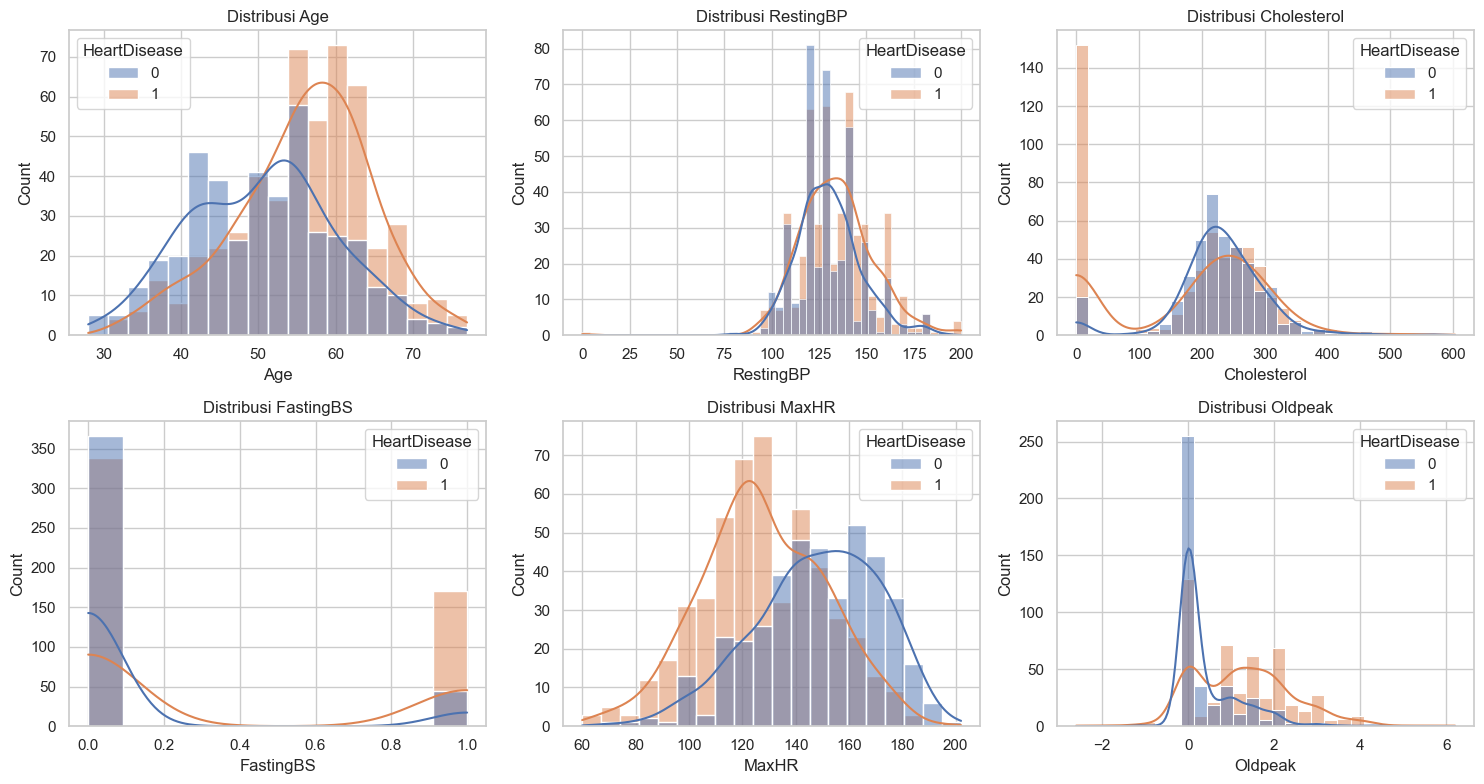

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, column in enumerate(numeric_columns):
    sns.histplot(data=raw_df, x=column, hue=TARGET_COLUMN, kde=True, ax=axes[idx])
    axes[idx].set_title(f"Distribusi {column}")

for idx in range(len(numeric_columns), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

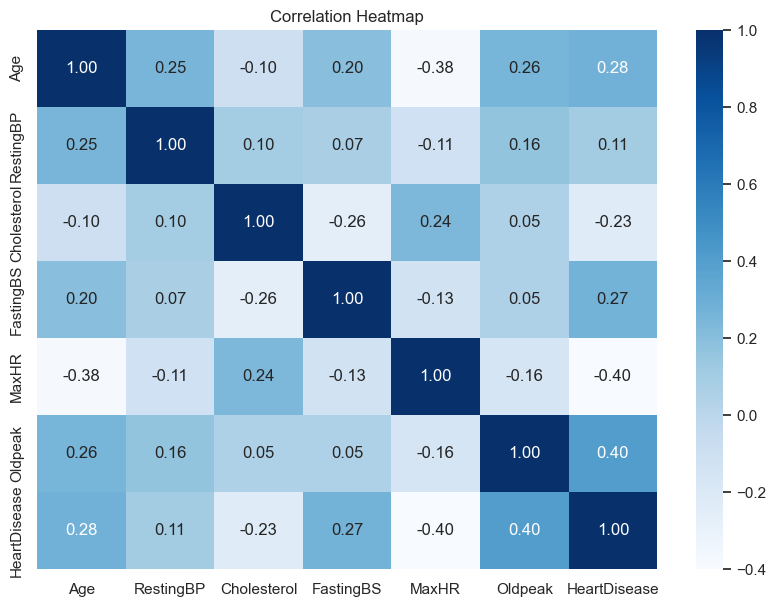

In [17]:
plt.figure(figsize=(10, 7))
sns.heatmap(raw_df[numeric_columns + [TARGET_COLUMN]].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

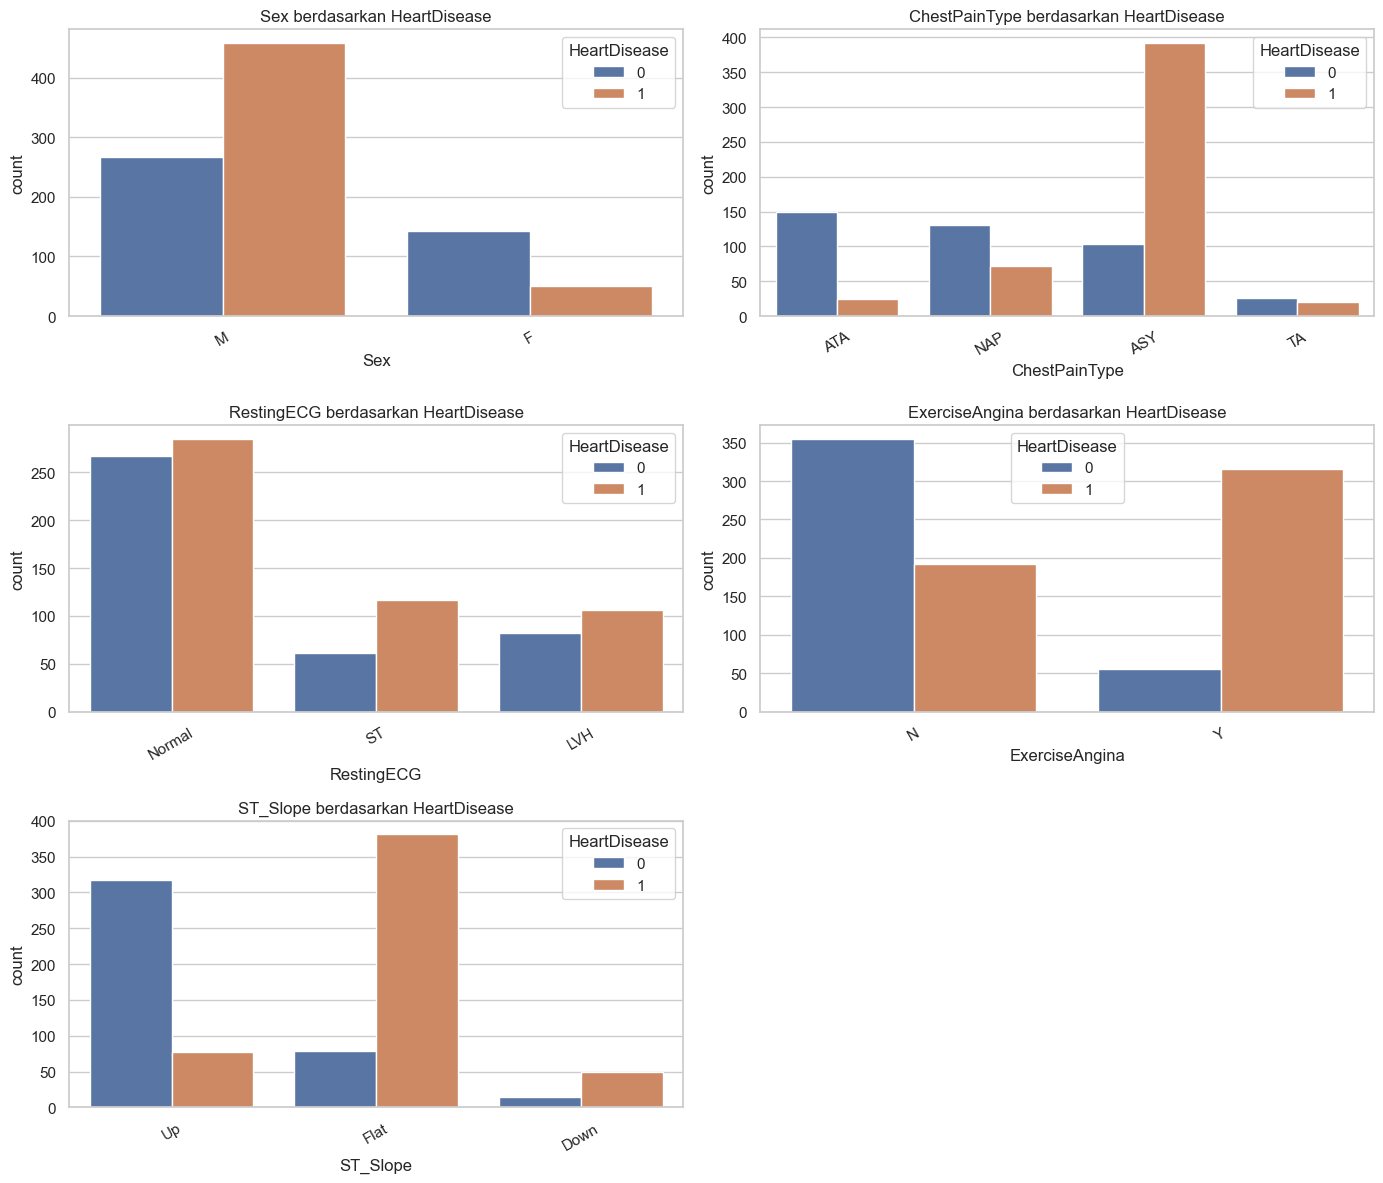

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, column in enumerate(categorical_columns):
    sns.countplot(data=raw_df, x=column, hue=TARGET_COLUMN, ax=axes[idx])
    axes[idx].set_title(f"{column} berdasarkan HeartDisease")
    axes[idx].tick_params(axis="x", rotation=30)

for idx in range(len(categorical_columns), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### 5.1 Menyalin Dataset Mentah

Dataset mentah disalin terlebih dahulu agar proses preprocessing tidak mengubah dataframe asli.

In [19]:
df = raw_df.copy()
print("Shape sebelum preprocessing:", df.shape)

Shape sebelum preprocessing: (918, 12)


### 5.2 Mengecek dan Menghapus Data Duplikat

Data duplikat perlu dicek karena baris yang berulang dapat membuat model bias terhadap pola tertentu.

In [20]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat sebelum dihapus: {duplicate_count}")

Jumlah data duplikat sebelum dihapus: 0


In [21]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape setelah menghapus duplikat:", df.shape)
print(f"Jumlah data duplikat setelah dihapus: {df.duplicated().sum()}")

Shape setelah menghapus duplikat: (918, 12)
Jumlah data duplikat setelah dihapus: 0


### 5.3 Mengecek Missing Value

Missing value dicek untuk memastikan tidak ada nilai kosong yang perlu diimputasi sebelum data masuk ke model.

In [22]:
missing_values_after_cleaning = df.isna().sum().sort_values(ascending=False)
display(missing_values_after_cleaning)
print(f"Total missing value: {missing_values_after_cleaning.sum()}")

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total missing value: 0


### 5.4 Memisahkan Fitur dan Target

Kolom `HeartDisease` digunakan sebagai target, sedangkan kolom lainnya digunakan sebagai fitur.

In [23]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(int)

print("Shape fitur:", X.shape)
print("Shape target:", y.shape)
display(y.value_counts().sort_index())

Shape fitur: (918, 11)
Shape target: (918,)


HeartDisease
0    410
1    508
Name: count, dtype: int64

### 5.5 Mengidentifikasi Kolom Numerik dan Kategorikal

Fitur numerik akan distandardisasi, sedangkan fitur kategorikal akan diubah menjadi representasi numerik dengan one-hot encoding.

In [24]:
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Kolom numerik:", numeric_columns)
print("Kolom kategorikal:", categorical_columns)

Kolom numerik: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Kolom kategorikal: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


### 5.6 Membagi Data Train dan Test

Data dibagi menjadi train dan test dengan stratifikasi agar proporsi kelas target tetap seimbang di kedua subset.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
display(y_train.value_counts().sort_index())
print("y_test distribution:")
display(y_test.value_counts().sort_index())

X_train: (734, 11)
X_test: (184, 11)
y_train distribution:


HeartDisease
0    328
1    406
Name: count, dtype: int64

y_test distribution:


HeartDisease
0     82
1    102
Name: count, dtype: int64

### 5.7 Membuat Transformer untuk Scaling dan Encoding

`StandardScaler` digunakan untuk fitur numerik dan `OneHotEncoder` digunakan untuk fitur kategorikal.

In [26]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", make_one_hot_encoder(), categorical_columns),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'RestingBP', 'Cholesterol',
                                  'FastingBS', 'MaxHR', 'Oldpeak']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Sex', 'ChestPainType', 'RestingECG',
                                  'ExerciseAngina', 'ST_Slope'])],
                  verbose_feature_names_out=False)

### 5.8 Melakukan Fit-Transform pada Data Train dan Transform pada Data Test

Preprocessor hanya di-fit pada data train untuk mencegah data leakage. Data test hanya menggunakan transform dari preprocessor yang sudah belajar dari data train.

In [27]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_names)

print("X_train setelah preprocessing:", X_train_df.shape)
print("X_test setelah preprocessing:", X_test_df.shape)
display(X_train_df.head())

X_train setelah preprocessing: (734, 20)
X_test setelah preprocessing: (184, 20)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.970012,0.339016,0.127137,1.835497,-0.324520,0.317046,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,0.122028,-1.266031,0.099443,1.835497,1.689837,-0.440356,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.546020,-0.159102,1.244113,1.835497,-0.247045,0.601071,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-0.725956,1.501291,-1.876035,-0.544812,-0.479470,-0.819056,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.407962,0.671094,-1.876035,1.835497,0.101594,-0.156330,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


### 5.9 Menggabungkan Kembali Fitur dan Target

Target digabungkan kembali agar dataset hasil preprocessing siap dipakai pada tahap modelling.

In [28]:
train_preprocessed = X_train_df.copy()
train_preprocessed[TARGET_COLUMN] = y_train.reset_index(drop=True)

test_preprocessed = X_test_df.copy()
test_preprocessed[TARGET_COLUMN] = y_test.reset_index(drop=True)

full_preprocessed = pd.concat([train_preprocessed, test_preprocessed], ignore_index=True)

print("Train preprocessed shape:", train_preprocessed.shape)
print("Test preprocessed shape:", test_preprocessed.shape)
print("Full preprocessed shape:", full_preprocessed.shape)
display(train_preprocessed.head())

Train preprocessed shape: (734, 21)
Test preprocessed shape: (184, 21)
Full preprocessed shape: (918, 21)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,0.970012,0.339016,0.127137,1.835497,-0.324520,0.317046,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1
1,0.122028,-1.266031,0.099443,1.835497,1.689837,-0.440356,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0
2,0.546020,-0.159102,1.244113,1.835497,-0.247045,0.601071,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1
3,-0.725956,1.501291,-1.876035,-0.544812,-0.479470,-0.819056,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
4,-0.407962,0.671094,-1.876035,1.835497,0.101594,-0.156330,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1


## 6. Menyimpan Dataset Hasil Preprocessing

Dataset hasil preprocessing disimpan ke folder `preprocessing/heart_failure_prediction_preprocessing`. File ini menjadi input untuk tahap membangun model machine learning.

In [30]:
OUTPUT_DIR = ROOT_DIR / "preprocessing" / "heart_failure_prediction_preprocessing"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_preprocessed.to_csv(OUTPUT_DIR / "train_preprocessed.csv", index=False)
test_preprocessed.to_csv(OUTPUT_DIR / "test_preprocessed.csv", index=False)
full_preprocessed.to_csv(OUTPUT_DIR / "heart_failure_detection_preprocessed.csv", index=False)
joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.joblib")

print("Dataset hasil preprocessing berhasil disimpan di:", OUTPUT_DIR)
print("File output:")
for output_path in sorted(OUTPUT_DIR.iterdir()):
    print("-", output_path.name)

Dataset hasil preprocessing berhasil disimpan di: d:\.Projek\Dicoding\MSML_Muhammad-Fauzan-Ashshidiq\Eksperimen_SML_Muhammad-Fauzan-Ashshidiq\preprocessing\heart_failure_prediction_preprocessing
File output:
- heart_failure_detection_preprocessed.csv
- preprocessor.joblib
- test_preprocessed.csv
- train_preprocessed.csv


## 7. Kesimpulan Eksperimen

Dataset Heart Failure Detection sudah berhasil dimuat, dianalisis, dan diproses. Kolom kategorikal sudah diubah menjadi fitur numerik dengan one-hot encoding, sedangkan fitur numerik sudah distandardisasi. Dataset hasil preprocessing siap digunakan untuk melatih model klasifikasi biner pada tahap berikutnya.